# Notebook 4 — Finale Case-Level-Fusion / Ablation (Stand C)

**Ziel:** Vier Varianten auf derselben Granularität vergleichen:
1. Metrics-only (XGBoost Case-Level, NB02)
2. Log-only (TF-IDF + LogReg, NB03)
3. AND-Fusion (binäres AND der Trigger)
4. Soft-Fusion / Product Score (Threshold aus Validation)

**Stand C — Kernänderungen gegenüber Stand B:**
- Lädt `metric_case_val_scores.csv` / `metric_case_test_scores.csv` (kein Row-Level-Aggregat mehr)
- Soft-Fusion-Threshold wird ausschließlich auf Validation-Scores bestimmt
- Kein Modell-Training in NB04

**Methodische Garantien:**
- Kein Modell-Training — nur Score-Fusion aus NB02/NB03-Artefakten
- Thresholds stammen ausschließlich aus Validation
- Testset nur für finale Evaluation
- Case-Granularität: eine Zeile pro case_id

**Input:** `docs/metric_case_val_scores.csv`, `docs/metric_case_test_scores.csv`,
`docs/log_val_scores.csv`, `docs/log_test_scores.csv`, `docs/split_assignments.csv`

**Output:** `docs/fusion_cases.csv`, `docs/fusion_val_scores.csv`,
`docs/final_results_table.csv`, `docs/fpr_by_dataset_type.csv`,
`docs/pr_curve_ablation.png`, `docs/fpr_comparison.png`

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    recall_score, confusion_matrix, precision_recall_curve,
    average_precision_score, f1_score, precision_score
)

docs_path = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_path, exist_ok=True)

print("Notebook 04 — Case-Level Fusion / Ablation (Stand C)")
print("docs_path: ../docs")

Notebook 04 — Case-Level Fusion / Ablation (Stand C)
docs_path: ../docs


In [2]:
# ─── Input-Artefakte laden ────────────────────────────────────────────────────
metric_val  = pd.read_csv(os.path.join(docs_path, "metric_case_val_scores.csv"))
metric_test = pd.read_csv(os.path.join(docs_path, "metric_case_test_scores.csv"))
log_val     = pd.read_csv(os.path.join(docs_path, "log_val_scores.csv"))
log_test    = pd.read_csv(os.path.join(docs_path, "log_test_scores.csv"))
split_df    = pd.read_csv(os.path.join(docs_path, "split_assignments.csv"))

# ─── Spalten robust erkennen und ggf. umbenennen ─────────────────────────────
# metric_pred → metric_trigger
for df_name, df in [('metric_val', metric_val), ('metric_test', metric_test)]:
    if 'metric_trigger' not in df.columns and 'metric_pred' in df.columns:
        df.rename(columns={'metric_pred': 'metric_trigger'}, inplace=True)
    assert 'metric_score'   in df.columns, f"{df_name}: Spalte 'metric_score' fehlt!"
    assert 'metric_trigger' in df.columns, f"{df_name}: Spalte 'metric_trigger' fehlt!"

# log_pred → log_trigger
for df_name, df in [('log_val', log_val), ('log_test', log_test)]:
    if 'log_trigger' not in df.columns and 'log_pred' in df.columns:
        df.rename(columns={'log_pred': 'log_trigger'}, inplace=True)
    assert 'log_score'   in df.columns, f"{df_name}: Spalte 'log_score' fehlt!"
    assert 'log_trigger' in df.columns, f"{df_name}: Spalte 'log_trigger' fehlt!"

# ─── Integrity Checks ─────────────────────────────────────────────────────────
val_case_ids  = set(split_df[split_df['split'] == 'val']['case_id'])
test_case_ids = set(split_df[split_df['split'] == 'test']['case_id'])

# Exakt 206 Val und 253 Test Cases
assert len(val_case_ids)  == 206, f"Erwarte 206 val cases, aber split_df hat {len(val_case_ids)}"
assert len(test_case_ids) == 253, f"Erwarte 253 test cases, aber split_df hat {len(test_case_ids)}"

# Val-Scores enthalten nur Val-Cases
assert set(metric_val['case_id']) == val_case_ids, \
    "metric_case_val_scores.csv: case_ids passen nicht zu val-Split!"
assert set(log_val['case_id']) == val_case_ids, \
    "log_val_scores.csv: case_ids passen nicht zu val-Split!"

# Test-Scores enthalten nur Test-Cases
assert set(metric_test['case_id']) == test_case_ids, \
    "metric_case_test_scores.csv: case_ids passen nicht zu test-Split!"
assert set(log_test['case_id']) == test_case_ids, \
    "log_test_scores.csv: case_ids passen nicht zu test-Split!"

# Val-Scores: metric und log müssen dieselben case_ids haben
assert set(metric_val['case_id']) == set(log_val['case_id']), \
    "case_id-Mismatch zwischen metric_case_val und log_val!"

# Test-Scores: metric und log müssen dieselben case_ids haben
assert set(metric_test['case_id']) == set(log_test['case_id']), \
    "case_id-Mismatch zwischen metric_case_test und log_test!"

# Keine Duplikate
for df_name, df in [('metric_val', metric_val), ('metric_test', metric_test),
                    ('log_val', log_val), ('log_test', log_test)]:
    assert df['case_id'].nunique() == len(df), \
        f"{df_name}: duplizierte case_ids gefunden!"

print(f"✓ metric_case_val_scores.csv    {len(metric_val)} cases")
print(f"✓ metric_case_test_scores.csv   {len(metric_test)} cases")
print(f"✓ log_val_scores.csv            {len(log_val)} cases")
print(f"✓ log_test_scores.csv           {len(log_test)} cases")
print(f"✓ split_assignments.csv         val={len(val_case_ids)}, test={len(test_case_ids)}")
print(f"\n✓ Alle Integritätsprüfungen bestanden")

# Label-Verteilung im Testset
n_test_total = len(metric_test)
n_mali_test  = int((metric_test['label'] == 1).sum())
n_anom_test  = int((metric_test['dataset_type'] == 'anom').sum())
n_norm_test  = int((metric_test['dataset_type'] == 'norm').sum())
n_neg_test   = n_anom_test + n_norm_test

print(f"\nTest-Set: {n_test_total} Cases — mali={n_mali_test}, anom={n_anom_test}, norm={n_norm_test}")
print(f"Threshold Metric (aus Val): {metric_val['threshold_metric_val'].iloc[0]:.6f}")
print(f"Threshold Log    (aus Val): {log_val['threshold_log_val'].iloc[0]:.6f}")

✓ metric_case_val_scores.csv    206 cases
✓ metric_case_test_scores.csv   253 cases
✓ log_val_scores.csv            206 cases
✓ log_test_scores.csv           253 cases
✓ split_assignments.csv         val=206, test=253

✓ Alle Integritätsprüfungen bestanden

Test-Set: 253 Cases — mali=48, anom=76, norm=129
Threshold Metric (aus Val): 0.025803
Threshold Log    (aus Val): 0.164056


## Methodische Absicherung der Fusion

| Schritt | Quelle | Guarantee |
|---|---|---|
| Metric-Threshold | NB02 (Validation) | Kein Test-Leakage |
| Log-Threshold | NB03 (Validation) | Kein Test-Leakage |
| Soft-Fusion-Threshold | Validation-Produkt-Scores (diese Zelle) | Kein Test-Leakage |
| AND-Trigger | metric_trigger AND log_trigger | Keine neue Optimierung |
| Testset | Nur finale Evaluation | Nie für Thresholds |

**Degeneration:** Falls metric_trigger fast immer 1 (FPR_total ≈ 1.0 bei Metrics-only),  
degeneriert AND-Fusion zu Log-only — wird im Ergebnis explizit berichtet.

In [3]:
# ─── Fusion DataFrames aufbauen ───────────────────────────────────────────────

# ── Test-Fusion-DataFrame ─────────────────────────────────────────────────────
fusion_test = metric_test[['case_id', 'dataset_type', 'scenario_id', 'group_id',
                            'label', 'metric_score', 'metric_trigger']].copy()
fusion_test = fusion_test.merge(
    log_test[['case_id', 'log_score', 'log_trigger']],
    on='case_id', how='inner'
)
assert len(fusion_test) == 253, f"Test-Fusion hat {len(fusion_test)} statt 253 Cases!"

# AND-Trigger
fusion_test['and_trigger'] = (
    (fusion_test['metric_trigger'] == 1) & (fusion_test['log_trigger'] == 1)
).astype(int)

# Produkt-Score
fusion_test['score_fusion'] = fusion_test['metric_score'] * fusion_test['log_score']
fusion_test['split'] = 'test'

# ── Val-Fusion-DataFrame ──────────────────────────────────────────────────────
fusion_val = metric_val[['case_id', 'dataset_type', 'scenario_id', 'group_id',
                          'label', 'metric_score', 'metric_trigger']].copy()
fusion_val = fusion_val.merge(
    log_val[['case_id', 'log_score', 'log_trigger']],
    on='case_id', how='inner'
)
assert len(fusion_val) == 206, f"Val-Fusion hat {len(fusion_val)} statt 206 Cases!"

# Produkt-Score auf Val
fusion_val['score_fusion'] = fusion_val['metric_score'] * fusion_val['log_score']
fusion_val['split'] = 'val'

# ── Soft-Fusion-Threshold: höchster Threshold mit Val-Recall_mali >= 0.95 ────
y_val        = fusion_val['label'].values
score_val    = fusion_val['score_fusion'].values

_, recalls_fusion_val, thresholds_fusion_val = precision_recall_curve(y_val, score_val)
ap_fusion_val = average_precision_score(y_val, score_val)

valid_thr_fusion = thresholds_fusion_val[recalls_fusion_val[:-1] >= 0.95]
threshold_soft = float(valid_thr_fusion.max()) if len(valid_thr_fusion) > 0 else float(thresholds_fusion_val[0])

val_recall_soft = recall_score(y_val, (score_val >= threshold_soft).astype(int))
fusion_val['soft_fusion_trigger'] = (fusion_val['score_fusion'] >= threshold_soft).astype(int)

# Soft-Fusion-Trigger auf Test
fusion_test['soft_fusion_trigger'] = (fusion_test['score_fusion'] >= threshold_soft).astype(int)

print(f"Soft-Fusion Threshold (aus Val):      {threshold_soft:.6f}")
print(f"Val-Recall_mali @ Threshold:          {val_recall_soft:.4f}")
print(f"Val-AP Produkt-Score:                 {ap_fusion_val:.4f}")
print(f"")
print(f"Test metric_trigger=1:  {fusion_test['metric_trigger'].sum()} / {len(fusion_test)}"  
      f" ({fusion_test['metric_trigger'].mean()*100:.1f}%)")
print(f"Test log_trigger=1:     {fusion_test['log_trigger'].sum()} / {len(fusion_test)}"  
      f" ({fusion_test['log_trigger'].mean()*100:.1f}%)")
print(f"Test and_trigger=1:     {fusion_test['and_trigger'].sum()} / {len(fusion_test)}"  
      f" ({fusion_test['and_trigger'].mean()*100:.1f}%)")
print(f"Test soft_trigger=1:    {fusion_test['soft_fusion_trigger'].sum()} / {len(fusion_test)}"  
      f" ({fusion_test['soft_fusion_trigger'].mean()*100:.1f}%)")

Soft-Fusion Threshold (aus Val):      0.004785


Val-Recall_mali @ Threshold:          0.9623
Val-AP Produkt-Score:                 0.7987

Test metric_trigger=1:  253 / 253 (100.0%)
Test log_trigger=1:     97 / 253 (38.3%)
Test and_trigger=1:     97 / 253 (38.3%)
Test soft_trigger=1:    99 / 253 (39.1%)


In [4]:
# ─── Helper: Variante evaluieren ──────────────────────────────────────────────
def eval_variant(df, y_true_col, y_pred_col, score_col, model_name,
                 threshold, threshold_source, has_continuous_score=True):
    """
    Berechnet alle Pflichtmetriken für eine Fusion-Variante.
    df: Test-DataFrame mit dataset_type, label, und Scores/Preds.
    """
    y_true  = df[y_true_col].values
    y_pred  = df[y_pred_col].values

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall_mali = float(recall_score(y_true, y_pred, zero_division=0))
    precision   = float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0
    f1          = float(f1_score(y_true, y_pred, zero_division=0))
    fpr_total   = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0

    # FPR getrennt nach anom / norm
    anom_mask = (df['dataset_type'] == 'anom').values
    norm_mask = (df['dataset_type'] == 'norm').values

    fp_anom = int(((y_pred == 1) & (y_true == 0) & anom_mask).sum())
    tn_anom = int(((y_pred == 0) & (y_true == 0) & anom_mask).sum())
    fpr_anom = fp_anom / (fp_anom + tn_anom) if (fp_anom + tn_anom) > 0 else 0.0

    fp_norm = int(((y_pred == 1) & (y_true == 0) & norm_mask).sum())
    tn_norm = int(((y_pred == 0) & (y_true == 0) & norm_mask).sum())
    fpr_norm = fp_norm / (fp_norm + tn_norm) if (fp_norm + tn_norm) > 0 else 0.0

    # AP nur wenn kontinuierlicher Score vorhanden
    if has_continuous_score and score_col in df.columns:
        ap = float(average_precision_score(y_true, df[score_col].values))
    else:
        ap = float('nan')

    n_test_total = len(df)
    n_mali_t  = int((df['dataset_type'] == 'mali').sum())
    n_anom_t  = int((df['dataset_type'] == 'anom').sum())
    n_norm_t  = int((df['dataset_type'] == 'norm').sum())

    return {
        'Model':            model_name,
        'Recall_mali':      round(recall_mali, 4),
        'Precision':        round(precision, 4),
        'F1':               round(f1, 4),
        'FPR_total':        round(fpr_total, 4),
        'FPR_anom':         round(fpr_anom, 4),
        'FPR_norm':         round(fpr_norm, 4),
        'AP':               round(ap, 4) if not np.isnan(ap) else 'N/A',
        'Threshold':        threshold,
        'Threshold_source': threshold_source,
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'n_test_cases':     n_test_total,
        'n_mali_test':      n_mali_t,
        'n_anom_test':      n_anom_t,
        'n_norm_test':      n_norm_t,
    }


def print_variant_result(r):
    ap_str = f"{r['AP']:.4f}" if isinstance(r['AP'], float) else r['AP']
    print(f"  Recall_mali: {r['Recall_mali']:.4f}   Precision: {r['Precision']:.4f}   F1: {r['F1']:.4f}")
    print(f"  FPR_total:   {r['FPR_total']:.4f}   FPR_anom:  {r['FPR_anom']:.4f}   FPR_norm: {r['FPR_norm']:.4f}")
    print(f"  AP: {ap_str}   Threshold: {r['Threshold']:.6f} ({r['Threshold_source']})")
    print(f"  TP={r['TP']}  FP={r['FP']}  TN={r['TN']}  FN={r['FN']}")
    if r['Recall_mali'] < 0.95:
        print(f"  [WARNUNG] Recall_mali < 0.95!")

print("✓ eval_variant() definiert")

✓ eval_variant() definiert


In [5]:
# ─── Variante 1: Metrics-only ─────────────────────────────────────────────────
threshold_metric = float(metric_test['threshold_metric_val'].iloc[0])

result_metric = eval_variant(
    df=fusion_test,
    y_true_col='label',
    y_pred_col='metric_trigger',
    score_col='metric_score',
    model_name='Metrics-only',
    threshold=round(threshold_metric, 6),
    threshold_source='metric_validation',
    has_continuous_score=True
)

print("=== Variante 1: Metrics-only ===")
print_variant_result(result_metric)
frac_metric_1 = fusion_test['metric_trigger'].mean()
print(f"  metric_trigger=1: {fusion_test['metric_trigger'].sum()} / {len(fusion_test)} ({frac_metric_1*100:.1f}%)")
if frac_metric_1 > 0.95:
    print("  [INFO] Metrics-only triggert fast alle Cases (FPR sehr hoch — Thesis-Hypothese bestätigt)")

=== Variante 1: Metrics-only ===
  Recall_mali: 1.0000   Precision: 0.1897   F1: 0.3189
  FPR_total:   1.0000   FPR_anom:  1.0000   FPR_norm: 1.0000
  AP: 0.2652   Threshold: 0.025803 (metric_validation)
  TP=48  FP=205  TN=0  FN=0
  metric_trigger=1: 253 / 253 (100.0%)
  [INFO] Metrics-only triggert fast alle Cases (FPR sehr hoch — Thesis-Hypothese bestätigt)


In [6]:
# ─── Variante 2: Log-only ─────────────────────────────────────────────────────
threshold_log = float(log_test['threshold_log_val'].iloc[0])

result_log = eval_variant(
    df=fusion_test,
    y_true_col='label',
    y_pred_col='log_trigger',
    score_col='log_score',
    model_name='Log-only',
    threshold=round(threshold_log, 6),
    threshold_source='log_validation',
    has_continuous_score=True
)

print("=== Variante 2: Log-only ===")
print_variant_result(result_log)

=== Variante 2: Log-only ===
  Recall_mali: 0.9375   Precision: 0.4639   F1: 0.6207
  FPR_total:   0.2537   FPR_anom:  0.2368   FPR_norm: 0.2636
  AP: 0.6548   Threshold: 0.164056 (log_validation)
  TP=45  FP=52  TN=153  FN=3
  [WARNUNG] Recall_mali < 0.95!


In [7]:
# ─── Variante 3: AND-Fusion ───────────────────────────────────────────────────
# Threshold: beide Komponenten-Thresholds gelten
threshold_and_str = f"{threshold_metric:.6f} & {threshold_log:.6f}"

result_and = eval_variant(
    df=fusion_test,
    y_true_col='label',
    y_pred_col='and_trigger',
    score_col=None,           # kein kontinuierlicher Score
    model_name='AND-Fusion',
    threshold=round(threshold_metric, 6),
    threshold_source='metric_and_log_validation',
    has_continuous_score=False
)

print("=== Variante 3: AND-Fusion ===")
print_variant_result(result_and)

# Degeneration prüfen
and_same_as_log = (fusion_test['and_trigger'] == fusion_test['log_trigger']).all()
print(f"\n  AND-Trigger identisch zu Log-only: {and_same_as_log}")
if and_same_as_log:
    print("  [INFO] Degeneration: metric_trigger ≈ 1 für alle Cases → AND degeneriert zu Log-only")

=== Variante 3: AND-Fusion ===
  Recall_mali: 0.9375   Precision: 0.4639   F1: 0.6207
  FPR_total:   0.2537   FPR_anom:  0.2368   FPR_norm: 0.2636
  AP: N/A   Threshold: 0.025803 (metric_and_log_validation)
  TP=45  FP=52  TN=153  FN=3
  [WARNUNG] Recall_mali < 0.95!

  AND-Trigger identisch zu Log-only: True
  [INFO] Degeneration: metric_trigger ≈ 1 für alle Cases → AND degeneriert zu Log-only


In [8]:
# ─── Variante 4: Soft-Fusion / Product Score ──────────────────────────────────
# Threshold wurde in Cell 04 aus Validation bestimmt

result_soft = eval_variant(
    df=fusion_test,
    y_true_col='label',
    y_pred_col='soft_fusion_trigger',
    score_col='score_fusion',
    model_name='Soft-Fusion',
    threshold=round(threshold_soft, 6),
    threshold_source='product_validation',
    has_continuous_score=True
)

print("=== Variante 4: Soft-Fusion (Product Score) ===")
print(f"  Threshold aus Val (Recall_mali >= 0.95): {threshold_soft:.6f}")
print(f"  Val-AP Produkt-Score:                    {ap_fusion_val:.4f}")
print_variant_result(result_soft)

# Vergleich mit Log-only
soft_better = result_soft['F1'] > result_log['F1']
print(f"\n  Soft-Fusion F1 ({result_soft['F1']:.4f}) vs Log-only F1 ({result_log['F1']:.4f}): "
      f"{'besser' if soft_better else 'schlechter/gleich'}")
if not soft_better:
    print("  [WARNUNG] Soft-Fusion verbessert F1 nicht gegenüber Log-only.")

=== Variante 4: Soft-Fusion (Product Score) ===
  Threshold aus Val (Recall_mali >= 0.95): 0.004785
  Val-AP Produkt-Score:                    0.7987
  Recall_mali: 0.9375   Precision: 0.4545   F1: 0.6122
  FPR_total:   0.2634   FPR_anom:  0.2500   FPR_norm: 0.2713
  AP: 0.5553   Threshold: 0.004785 (product_validation)
  TP=45  FP=54  TN=151  FN=3
  [WARNUNG] Recall_mali < 0.95!

  Soft-Fusion F1 (0.6122) vs Log-only F1 (0.6207): schlechter/gleich
  [WARNUNG] Soft-Fusion verbessert F1 nicht gegenüber Log-only.


In [9]:
# ─── final_results_table.csv ─────────────────────────────────────────────────
results_list = [result_metric, result_log, result_and, result_soft]
final_results_df = pd.DataFrame(results_list)

final_results_df.to_csv(os.path.join(docs_path, "final_results_table.csv"), index=False)
print("✓ final_results_table.csv gespeichert")
print()

# Schöne Ausgabe
display_cols = ['Model', 'Recall_mali', 'Precision', 'F1', 'FPR_anom', 'FPR_norm', 'FPR_total', 'AP',
                'Threshold', 'Threshold_source', 'TP', 'FP', 'TN', 'FN']
print("=== Finale Ergebnistabelle ===")
print(final_results_df[display_cols].to_string(index=False))

# ─── fpr_by_dataset_type.csv ──────────────────────────────────────────────────
fpr_rows = []
for res, pred_col in [
    ('Metrics-only', 'metric_trigger'),
    ('Log-only',     'log_trigger'),
    ('AND-Fusion',   'and_trigger'),
    ('Soft-Fusion',  'soft_fusion_trigger'),
]:
    y_pred_col = fusion_test[pred_col].values
    y_true_col = fusion_test['label'].values
    for dtype in ['anom', 'norm']:
        mask = (fusion_test['dataset_type'] == dtype).values
        # Only negative cases for FPR
        neg_mask = (y_true_col == 0) & mask
        fp_c = int((y_pred_col[neg_mask] == 1).sum())
        total_c = int(neg_mask.sum())
        fpr_c = fp_c / total_c if total_c > 0 else 0.0
        fpr_rows.append({
            'Model':           res,
            'dataset_type':    dtype,
            'false_positives': fp_c,
            'total_negatives': total_c,
            'FPR':             round(fpr_c, 4),
        })

fpr_by_dtype_df = pd.DataFrame(fpr_rows)
fpr_by_dtype_df.to_csv(os.path.join(docs_path, "fpr_by_dataset_type.csv"), index=False)
print(f"\n✓ fpr_by_dataset_type.csv gespeichert")
print(fpr_by_dtype_df.to_string(index=False))

✓ final_results_table.csv gespeichert

=== Finale Ergebnistabelle ===
       Model  Recall_mali  Precision     F1  FPR_anom  FPR_norm  FPR_total      AP  Threshold          Threshold_source  TP  FP  TN  FN
Metrics-only       1.0000     0.1897 0.3189    1.0000    1.0000     1.0000  0.2652   0.025803         metric_validation  48 205   0   0
    Log-only       0.9375     0.4639 0.6207    0.2368    0.2636     0.2537  0.6548   0.164056            log_validation  45  52 153   3
  AND-Fusion       0.9375     0.4639 0.6207    0.2368    0.2636     0.2537     N/A   0.025803 metric_and_log_validation  45  52 153   3
 Soft-Fusion       0.9375     0.4545 0.6122    0.2500    0.2713     0.2634  0.5553   0.004785        product_validation  45  54 151   3

✓ fpr_by_dataset_type.csv gespeichert
       Model dataset_type  false_positives  total_negatives    FPR
Metrics-only         anom               76               76 1.0000
Metrics-only         norm              129              129 1.0000
    Log-on

In [10]:
# ─── fusion_cases.csv und fusion_val_scores.csv ───────────────────────────────

# fusion_cases.csv — Test-Cases
fusion_cases_out = fusion_test[[
    'case_id', 'dataset_type', 'scenario_id', 'group_id', 'label',
    'metric_score', 'metric_trigger',
    'log_score', 'log_trigger',
    'and_trigger', 'score_fusion', 'soft_fusion_trigger',
    'split'
]].copy()
fusion_cases_out.to_csv(os.path.join(docs_path, "fusion_cases.csv"), index=False)
print(f"✓ fusion_cases.csv gespeichert ({len(fusion_cases_out)} Test-Cases)")

# Integrität prüfen
assert len(fusion_cases_out) == 253, "fusion_cases.csv sollte 253 Test-Cases haben!"
assert fusion_cases_out['case_id'].nunique() == 253, "fusion_cases.csv: duplizierte case_ids!"
assert (fusion_cases_out['split'] == 'test').all(), "fusion_cases.csv enthält Nicht-Test-Cases!"

# fusion_val_scores.csv — Val-Cases
fusion_val_out = fusion_val[[
    'case_id', 'dataset_type', 'scenario_id', 'group_id', 'label',
    'metric_score', 'metric_trigger',
    'log_score', 'log_trigger',
    'score_fusion', 'soft_fusion_trigger',
    'split'
]].copy()
fusion_val_out.to_csv(os.path.join(docs_path, "fusion_val_scores.csv"), index=False)
print(f"✓ fusion_val_scores.csv gespeichert ({len(fusion_val_out)} Val-Cases)")

# Integrität prüfen
assert len(fusion_val_out) == 206, "fusion_val_scores.csv sollte 206 Val-Cases haben!"
assert fusion_val_out['case_id'].nunique() == 206, "fusion_val_scores.csv: duplizierte case_ids!"
assert (fusion_val_out['split'] == 'val').all(), "fusion_val_scores.csv enthält Nicht-Val-Cases!"

print("\n✓ Alle Artefakt-Integritätsprüfungen bestanden")

✓ fusion_cases.csv gespeichert (253 Test-Cases)
✓ fusion_val_scores.csv gespeichert (206 Val-Cases)

✓ Alle Artefakt-Integritätsprüfungen bestanden


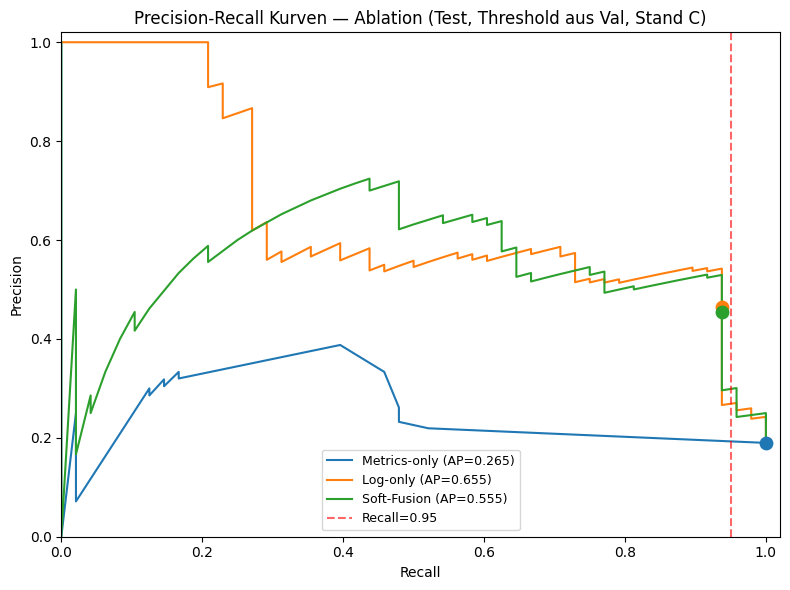

✓ pr_curve_ablation.png gespeichert (AND-Gate ausgelassen — kein kontinuierlicher Score)


In [11]:
# ─── PR-Kurven-Ablation (Metrics-only, Log-only, Soft-Fusion) ─────────────────
y_true_test = fusion_test['label'].values

curves = [
    ('Metrics-only', fusion_test['metric_score'].values, result_metric),
    ('Log-only',     fusion_test['log_score'].values,    result_log),
    ('Soft-Fusion',  fusion_test['score_fusion'].values, result_soft),
]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for (name, scores, res), color in zip(curves, colors):
    prec_c, rec_c, _ = precision_recall_curve(y_true_test, scores)
    ap_val_str = f"{res['AP']:.3f}" if isinstance(res['AP'], float) else res['AP']
    ax.plot(rec_c, prec_c, label=f"{name} (AP={ap_val_str})", color=color)
    # Threshold-Punkt markieren
    ax.scatter([res['Recall_mali']], [res['Precision']],
               color=color, s=80, zorder=5)

ax.axvline(x=0.95, color='red', linestyle='--', alpha=0.6, label='Recall=0.95')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurven — Ablation (Test, Threshold aus Val, Stand C)')
ax.legend(fontsize=9)
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "pr_curve_ablation.png"), dpi=150)
plt.show()
print("✓ pr_curve_ablation.png gespeichert (AND-Gate ausgelassen — kein kontinuierlicher Score)")

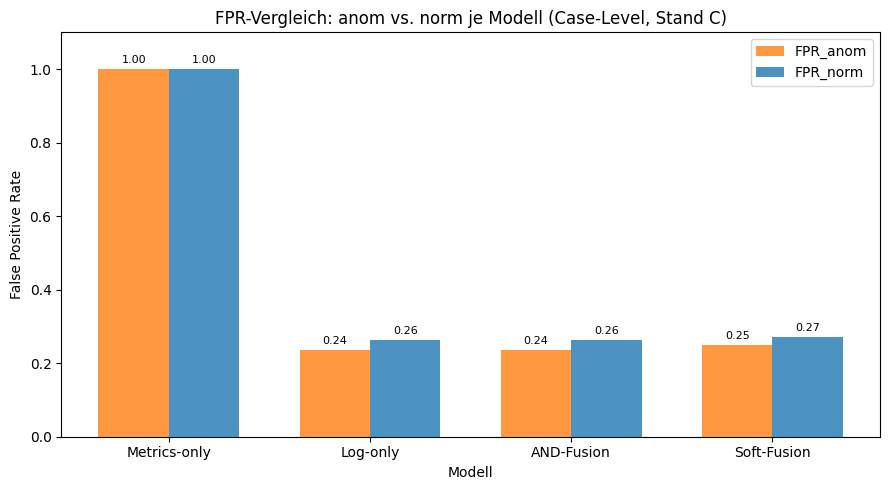

✓ fpr_comparison.png gespeichert


In [12]:
# ─── FPR-Vergleich: FPR_anom und FPR_norm je Modell ──────────────────────────
models     = ['Metrics-only', 'Log-only', 'AND-Fusion', 'Soft-Fusion']
fpr_anom_v = [result_metric['FPR_anom'], result_log['FPR_anom'],
              result_and['FPR_anom'],    result_soft['FPR_anom']]
fpr_norm_v = [result_metric['FPR_norm'], result_log['FPR_norm'],
              result_and['FPR_norm'],    result_soft['FPR_norm']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_anom = ax.bar(x - width/2, fpr_anom_v, width, label='FPR_anom', color='tab:orange', alpha=0.8)
bars_norm = ax.bar(x + width/2, fpr_norm_v, width, label='FPR_norm', color='tab:blue',   alpha=0.8)

ax.set_xlabel('Modell')
ax.set_ylabel('False Positive Rate')
ax.set_title('FPR-Vergleich: anom vs. norm je Modell (Case-Level, Stand C)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim([0, 1.1])
ax.legend()

for bar in bars_anom:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars_norm:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(docs_path, "fpr_comparison.png"), dpi=150)
plt.show()
print("✓ fpr_comparison.png gespeichert")

## Ergebniszusammenfassung (Stand C)

*Aktuelle Werte nach dem Ausführen der Zellen oben:*

| Modell | Recall_mali | FPR_total | FPR_anom | FPR_norm | AP | F1 |
|---|---|---|---|---|---|---|
| Metrics-only | Cell 06 | Cell 06 | Cell 06 | Cell 06 | Cell 06 | Cell 06 |
| Log-only | Cell 07 | Cell 07 | Cell 07 | Cell 07 | Cell 07 | Cell 07 |
| AND-Fusion | Cell 08 | Cell 08 | Cell 08 | Cell 08 | N/A | Cell 08 |
| Soft-Fusion | Cell 09 | Cell 09 | Cell 09 | Cell 09 | Cell 09 | Cell 09 |

**Artefakte:**
- `docs/fusion_cases.csv` → 253 Test-Cases mit allen Scores/Triggern
- `docs/fusion_val_scores.csv` → 206 Val-Cases mit Scores/Triggern
- `docs/final_results_table.csv` → Kompakte Ergebnistabelle für Betreuer
- `docs/fpr_by_dataset_type.csv` → FPR-Breakdown nach dataset_type
- `docs/pr_curve_ablation.png` → PR-Kurven (3 Modelle mit kontinuierlichem Score)
- `docs/fpr_comparison.png` → FPR-Vergleich anom vs. norm je Modell

**Soft-Fusion-Threshold:** Aus Validation-Produkt-Scores bestimmt (Recall_mali ≥ 0.95).  
Kein Testset-Bias — Threshold vor Test-Evaluation eingefroren.